# Telco Customer Churn Analysis

## Objective

The objective of this project is to analyze customer churn behavior in a telecom company and identify the major factors contributing to customer attrition. The analysis aims to discover high-risk customer segments, understand churn drivers, and provide business recommendations to improve customer retention.

## Business Problem Understanding

### What is Customer Churn?

Customer churn refers to customers discontinuing a company’s services within a given period.

### Why is Churn Important?

Customer churn directly impacts company revenue and profitability. Retaining existing customers is often more cost-effective than acquiring new customers.

# Importing Libraries

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

### Loading Dataset

In [2]:
df = pd.read_csv(r"C:\Users\SRIKANT SENAPATI\OneDrive\Desktop\Telco-Customer-Churn.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Data cleaning part

In [4]:
df.shape

(7043, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.columns = df.columns.str.lower().str.replace(' ','_').str.strip()

In [9]:
df.columns

Index(['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents',
       'tenure', 'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod', 'monthlycharges', 'totalcharges', 'churn'],
      dtype='object')

In [10]:
df['totalcharges'] = pd.to_numeric(df['totalcharges'], errors='coerce')

In [11]:
df.isnull().sum()

customerid           0
gender               0
seniorcitizen        0
partner              0
dependents           0
tenure               0
phoneservice         0
multiplelines        0
internetservice      0
onlinesecurity       0
onlinebackup         0
deviceprotection     0
techsupport          0
streamingtv          0
streamingmovies      0
contract             0
paperlessbilling     0
paymentmethod        0
monthlycharges       0
totalcharges        11
churn                0
dtype: int64

In [12]:
df['totalcharges'] = df['totalcharges'].fillna(0)

In [13]:
df.dtypes

customerid           object
gender               object
seniorcitizen         int64
partner              object
dependents           object
tenure                int64
phoneservice         object
multiplelines        object
internetservice      object
onlinesecurity       object
onlinebackup         object
deviceprotection     object
techsupport          object
streamingtv          object
streamingmovies      object
contract             object
paperlessbilling     object
paymentmethod        object
monthlycharges      float64
totalcharges        float64
churn                object
dtype: object

In [14]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerid        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   seniorcitizen     7043 non-null   int64  
 3   partner           7043 non-null   object 
 4   dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   phoneservice      7043 non-null   object 
 7   multiplelines     7043 non-null   object 
 8   internetservice   7043 non-null   object 
 9   onlinesecurity    7043 non-null   object 
 10  onlinebackup      7043 non-null   object 
 11  deviceprotection  7043 non-null   object 
 12  techsupport       7043 non-null   object 
 13  streamingtv       7043 non-null   object 
 14  streamingmovies   7043 non-null   object 
 15  contract          7043 non-null   object 
 16  paperlessbilling  7043 non-null   object 


customerid          0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        0
churn               0
dtype: int64

In [15]:
columns = [
    'multiplelines',
    'onlinesecurity',
    'onlinebackup',
    'deviceprotection',
    'techsupport',
    'streamingtv',
    'streamingmovies'
]

for col in columns:
    df[col] = df[col].str.replace('No internet service', 'No')
    df[col] = df[col].str.replace('No phone service', 'No')

In [16]:
df['paymentmethod'] = df['paymentmethod'].str.replace(' (automatic)', '', regex=False)

In [17]:
df.columns = [
    'customer_id',
    'gender',
    'senior_citizen',
    'partner',
    'dependents',
    'tenure',
    'phone_service',
    'multiple_lines',
    'internet_service',
    'online_security',
    'online_backup',
    'device_protection',
    'tech_support',
    'streaming_tv',
    'streaming_movies',
    'contract',
    'paperless_billing',
    'payment_method',
    'monthly_charges',
    'total_charges',
    'churn'
]

# Cleaned Dataset

In [18]:
df.to_csv(r"C:\Users\SRIKANT SENAPATI\OneDrive\Desktop\cleaned_telco_customer_churn.csv",index=False)

# Data Analysis

## Churn vs Non-Churn Comparison

This analysis compares customers who have stayed with the company to customers who have churned. The understanding of the distribution assists to identify the overall churn pattern of the telecom business.

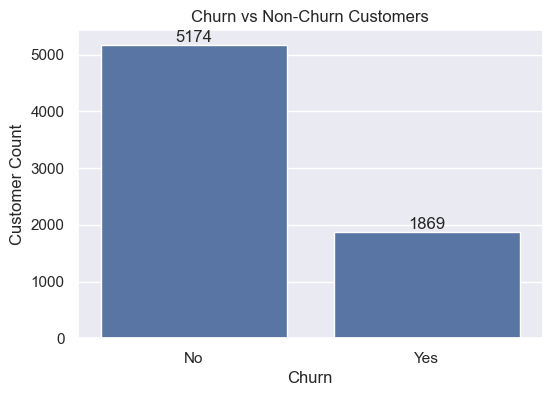

In [19]:
plt.figure(figsize=(6,4))

sns.set_theme(style="darkgrid",palette="deep")

ax = sns.countplot(x='churn', data=df)

plt.title("Churn vs Non-Churn Customers")
plt.xlabel("Churn")
plt.ylabel("Customer Count")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

### Insight

The number of non-churn customers is higher than churn customers. However, a significant portion of customers have discontinued the service, indicating the importance of customer retention strategies.

## Contract Type vs Churn

This analysis examines how different contract types influence customer churn behavior.

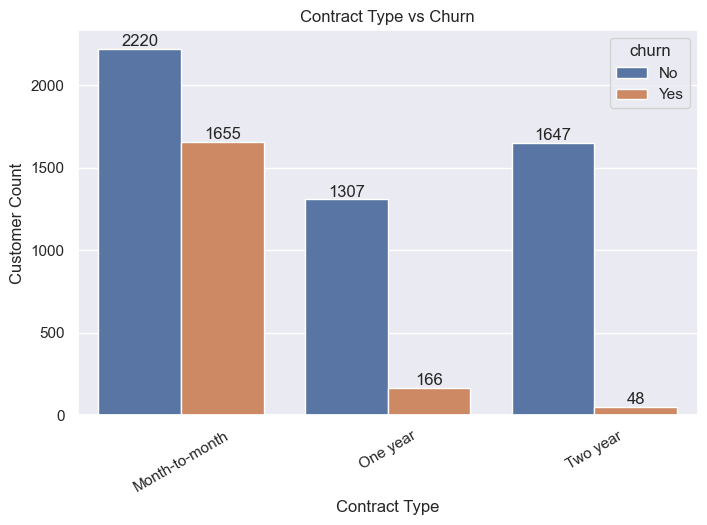

In [20]:
plt.figure(figsize=(8,5))

ax = sns.countplot(x='contract', hue='churn', data=df)

plt.title("Contract Type vs Churn")
plt.xlabel("Contract Type")
plt.ylabel("Customer Count")

for container in ax.containers:
    ax.bar_label(container)

plt.xticks(rotation=30)

plt.show()

### Insight

Customers with month-to-month contracts show significantly higher churn compared to customers with long-term contracts.

## Monthly Charges vs Churn

This analysis studies the relationship between monthly charges and customer churn.

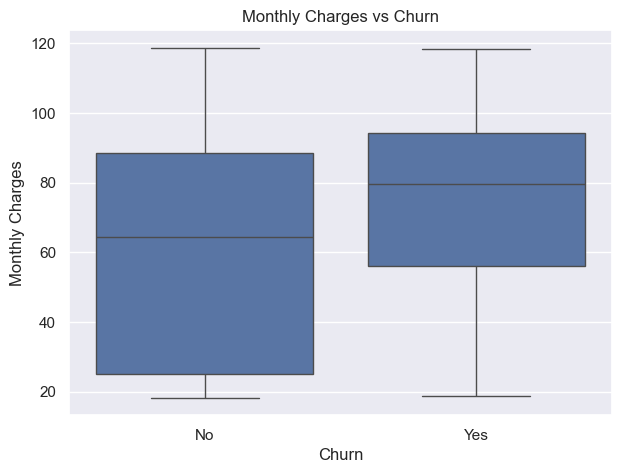

In [21]:
plt.figure(figsize=(7,5))

sns.boxplot(x='churn', y='monthly_charges', data=df)

plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

### Insight

Customers with higher monthly charges show a higher tendency to churn. The median monthly charges for churned customers are significantly higher than non-churn customers, indicating that pricing may be an important factor influencing customer attrition.

# Segmentation

## High-Risk Customers

High-risk customers are customers who are more likely to churn based on their contract type, monthly charges, and tenure.

In [22]:
high_risk = df[(df['contract'] == 'Month-to-month') | (df['monthly_charges'] > 70)]
high_risk.head()

,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,...,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card,89.10,1949.40,No


High-risk customers

In [23]:
high_risk.shape[0]

5361

### Insight

Customers with month-to-month contracts and high monthly charges are identified as high-risk customers because they show a higher likelihood of churn.

## Loyal Customers

Loyal customers are customers who have stayed with the company for a long period and are less likely to churn.

In [24]:
loyal_customers = df[df['tenure'] > 60]
loyal_customers.head()

,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,...,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer,56.15,3487.95,No
15,3655-SNQYZ,Female,0,Yes,Yes,69,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,No,Credit card,113.25,7895.15,No
17,9959-WOFKT,Male,0,No,Yes,71,Yes,Yes,Fiber optic,Yes,...,Yes,No,Yes,Yes,Two year,No,Bank transfer,106.70,7382.25,No
28,5248-YGIJN,Male,0,Yes,No,72,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Credit card,90.25,6369.45,No
30,3841-NFECX,Female,1,Yes,No,71,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,No,No,Two year,Yes,Credit card,96.35,6766.95,No


Loyal customers 

In [25]:
loyal_customers.shape[0]

1407

### Insight

Customers with higher tenure are considered loyal customers because they have maintained long-term relationships with the company.

## Key Performance Indicators (KPIs)

In [26]:
churn_rate = round(df['churn'].value_counts(normalize=True) * 100, 2)
print(churn_rate)

churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


### Insight

Approximately 73.46% of customers remained with the company, while 26.54% of customers churned. Although the majority of customers were retained, the churn rate is still significant, indicating the need for effective customer retention strategies to reduce revenue loss and improve customer satisfaction.

### Average Revenue Per User (ARPU)

ARPU measures the average monthly revenue generated per customer.

In [27]:
arpu = round(df['monthly_charges'].mean(),2)
print("Average Revenue Per User (ARPU):",arpu)

Average Revenue Per User (ARPU): 64.76


### Insight

The Average Revenue Per User (ARPU) is 64.76, indicating that each customer generates an average monthly revenue of approximately $64.76 for the company. This metric helps evaluate overall revenue performance and customer value contribution.

## Basic Churn Prediction


### Encoding Categorical Columns

In [28]:
le = LabelEncoder()

for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = le.fit_transform(df[column])

### Defining Features and Target

In [29]:
X = df.drop('churn', axis=1)
y = df['churn']

### Applying Train-Test Split

In [30]:
X_train, X_test, y_train, y_test = train_test_split( X, y,test_size=0.2,random_state=42)

### Model Training

In [31]:
model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [32]:
y_pred = model.predict(X_test)

accuracy = round(accuracy_score(y_test, y_pred)*100,2)

print("Model Accuracy:",accuracy,'%')

Model Accuracy: 81.48 %


### Insight

The churn prediction model achieved an accuracy of 81.48%, indicating that the model can effectively identify customers who are likely to churn. This suggests that customer demographics, contract type, tenure, and service-related features have a strong influence on customer churn behavior.